In [1]:
# %%
# nn.py

In [2]:
# %%
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import neural_network
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.random_projection import GaussianRandomProjection

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)

In [3]:
# %%
# Load the Breast Cancer dataset
bc_data = load_breast_cancer()
X = bc_data.data
y = bc_data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode the target
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# %%
# Apply dimensionality reduction techniques with the specified number of components
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

ica = FastICA(n_components=28, random_state=42)
X_train_ica = ica.fit_transform(X_train)
X_test_ica = ica.transform(X_test)

rp = GaussianRandomProjection(n_components=29, random_state=42)
X_train_rp = rp.fit_transform(X_train)
X_test_rp = rp.transform(X_test)

In [5]:
# %%
# Train a neural network classifier
NeuralNetwork = neural_network.MLPClassifier(max_iter=3000, random_state=42)
param_grid = {
    "hidden_layer_sizes": np.arange(2, 50, 2),
    "activation": ["logistic", "relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [0.001, 0.01, 0.1],
    "learning_rate": ["invscaling", "adaptive"],
    "learning_rate_init": [0.001, 0.01, 0.1],
}


def fit_and_evaluate(X_train, X_test, y_train, y_test, method_name):
    NeuralNetworkCV = GridSearchCV(
        NeuralNetwork, param_grid, cv=5, n_jobs=-1, verbose=0
    )

    start_time = time.time()
    NeuralNetworkCV.fit(X_train, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    print(f"Training time ({method_name}): {training_time:.2f} seconds")
    print(f"Best parameters ({method_name}): {NeuralNetworkCV.best_params_}")

    NeuralNetworkCV.predict(X_train)
    y_test_pred = NeuralNetworkCV.predict(X_test)

    train_score = NeuralNetworkCV.score(X_train, y_train)
    test_score = NeuralNetworkCV.score(X_test, y_test)
    print(f"Train accuracy ({method_name}): {train_score:.4f}")
    print(f"Test accuracy ({method_name}): {test_score:.4f}")

    precision = precision_score(y_test, y_test_pred, average="weighted")
    recall = recall_score(y_test, y_test_pred, average="weighted")
    f1 = f1_score(y_test, y_test_pred, average="weighted")
    roc_auc = roc_auc_score(y_test, y_test_pred, average="weighted")

    print(f"Precision ({method_name}): {precision:.4f}")
    print(f"Recall ({method_name}): {recall:.4f}")
    print(f"F1 Score ({method_name}): {f1:.4f}")
    print(f"ROC AUC Score ({method_name}): {roc_auc:.4f}")

    cm = confusion_matrix(y_test.argmax(axis=1), y_test_pred.argmax(axis=1))
    cm_df = pd.DataFrame(cm, index=bc_data.target_names, columns=bc_data.target_names)

    BestNeuralNetwork = NeuralNetworkCV.best_estimator_
    train_sizes, train_scores, test_scores = learning_curve(
        BestNeuralNetwork,
        X_train,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 20),
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    return (
        train_sizes,
        train_scores_mean,
        train_scores_std,
        test_scores_mean,
        test_scores_std,
        NeuralNetworkCV.best_estimator_,
        train_score,
        test_score,
        training_time,
        precision,
        recall,
        f1,
        roc_auc,
        cm_df,
    )

In [6]:
# %%
# Evaluate on original data
(
    train_sizes_original,
    train_scores_mean_original,
    train_scores_std_original,
    test_scores_mean_original,
    test_scores_std_original,
    best_nn_original,
    train_score_original,
    test_score_original,
    training_time_original,
    precision_original,
    recall_original,
    f1_original,
    roc_auc_original,
    cm_df_original,
) = fit_and_evaluate(X_train, X_test, y_train, y_test, "Original")

# Evaluate on PCA data
(
    train_sizes_pca,
    train_scores_mean_pca,
    train_scores_std_pca,
    test_scores_mean_pca,
    test_scores_std_pca,
    best_nn_pca,
    train_score_pca,
    test_score_pca,
    training_time_pca,
    precision_pca,
    recall_pca,
    f1_pca,
    roc_auc_pca,
    cm_df_pca,
) = fit_and_evaluate(X_train_pca, X_test_pca, y_train, y_test, "PCA")

# Evaluate on ICA data
(
    train_sizes_ica,
    train_scores_mean_ica,
    train_scores_std_ica,
    test_scores_mean_ica,
    test_scores_std_ica,
    best_nn_ica,
    train_score_ica,
    test_score_ica,
    training_time_ica,
    precision_ica,
    recall_ica,
    f1_ica,
    roc_auc_ica,
    cm_df_ica,
) = fit_and_evaluate(X_train_ica, X_test_ica, y_train, y_test, "ICA")

# Evaluate on RP data
(
    train_sizes_rp,
    train_scores_mean_rp,
    train_scores_std_rp,
    test_scores_mean_rp,
    test_scores_std_rp,
    best_nn_rp,
    train_score_rp,
    test_score_rp,
    training_time_rp,
    precision_rp,
    recall_rp,
    f1_rp,
    roc_auc_rp,
    cm_df_rp,
) = fit_and_evaluate(X_train_rp, X_test_rp, y_train, y_test, "RP")

Training time (Original): 224.83 seconds
Best parameters (Original): {'activation': 'logistic', 'alpha': 0.1, 'hidden_layer_sizes': np.int64(42), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (Original): 0.9824
Test accuracy (Original): 0.9912
Precision (Original): 0.9913
Recall (Original): 0.9912
F1 Score (Original): 0.9912
ROC AUC Score (Original): 0.9884
Training time (PCA): 231.27 seconds
Best parameters (PCA): {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': np.int64(48), 'learning_rate': 'invscaling', 'learning_rate_init': 0.01, 'solver': 'adam'}
Train accuracy (PCA): 1.0000
Test accuracy (PCA): 0.9737
Precision (PCA): 0.9740
Recall (PCA): 0.9737
F1 Score (PCA): 0.9737
ROC AUC Score (PCA): 0.9743


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached 

Training time (ICA): 247.38 seconds
Best parameters (ICA): {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': np.int64(6), 'learning_rate': 'adaptive', 'learning_rate_init': 0.1, 'solver': 'sgd'}
Train accuracy (ICA): 1.0000
Test accuracy (ICA): 0.9474
Precision (ICA): 0.9487
Recall (ICA): 0.9561
F1 Score (ICA): 0.9522
ROC AUC Score (ICA): 0.9530


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached 

Training time (RP): 243.30 seconds
Best parameters (RP): {'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': np.int64(40), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (RP): 0.9890
Test accuracy (RP): 0.9561
Precision (RP): 0.9565
Recall (RP): 0.9561
F1 Score (RP): 0.9562
ROC AUC Score (RP): 0.9556


In [7]:
# %%
# Save confusion matrices to Excel
confusion_matrices = pd.DataFrame(
    {
        "Original": cm_df_original.to_numpy().tolist(),
        "PCA": cm_df_pca.to_numpy().tolist(),
        "ICA": cm_df_ica.to_numpy().tolist(),
        "RP": cm_df_rp.to_numpy().tolist(),
    }
)

confusion_matrices.to_excel("./result/nn_confusion_matrices.xlsx", index=False)

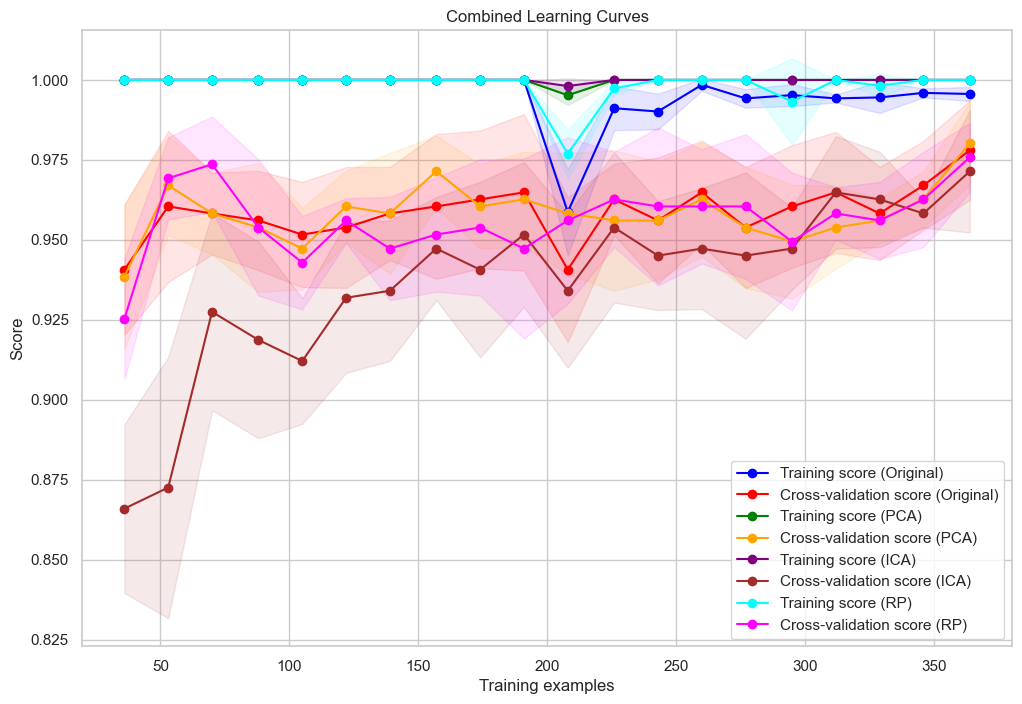

In [8]:
# %%
# Combine learning curve plots
plt.figure(figsize=(12, 8))

# Original data learning curve
plt.fill_between(
    train_sizes_original,
    train_scores_mean_original - train_scores_std_original,
    train_scores_mean_original + train_scores_std_original,
    alpha=0.1,
    color="blue",
)
plt.fill_between(
    train_sizes_original,
    test_scores_mean_original - test_scores_std_original,
    test_scores_mean_original + test_scores_std_original,
    alpha=0.1,
    color="red",
)
plt.plot(
    train_sizes_original,
    train_scores_mean_original,
    "o-",
    color="blue",
    label="Training score (Original)",
)
plt.plot(
    train_sizes_original,
    test_scores_mean_original,
    "o-",
    color="red",
    label="Cross-validation score (Original)",
)

# PCA data learning curve
plt.fill_between(
    train_sizes_pca,
    train_scores_mean_pca - train_scores_std_pca,
    train_scores_mean_pca + train_scores_std_pca,
    alpha=0.1,
    color="green",
)
plt.fill_between(
    train_sizes_pca,
    test_scores_mean_pca - test_scores_std_pca,
    test_scores_mean_pca + test_scores_std_pca,
    alpha=0.1,
    color="orange",
)
plt.plot(
    train_sizes_pca,
    train_scores_mean_pca,
    "o-",
    color="green",
    label="Training score (PCA)",
)
plt.plot(
    train_sizes_pca,
    test_scores_mean_pca,
    "o-",
    color="orange",
    label="Cross-validation score (PCA)",
)

# ICA data learning curve
plt.fill_between(
    train_sizes_ica,
    train_scores_mean_ica - train_scores_std_ica,
    train_scores_mean_ica + train_scores_std_ica,
    alpha=0.1,
    color="purple",
)
plt.fill_between(
    train_sizes_ica,
    test_scores_mean_ica - test_scores_std_ica,
    test_scores_mean_ica + test_scores_std_ica,
    alpha=0.1,
    color="brown",
)
plt.plot(
    train_sizes_ica,
    train_scores_mean_ica,
    "o-",
    color="purple",
    label="Training score (ICA)",
)
plt.plot(
    train_sizes_ica,
    test_scores_mean_ica,
    "o-",
    color="brown",
    label="Cross-validation score (ICA)",
)

# RP data learning curve
plt.fill_between(
    train_sizes_rp,
    train_scores_mean_rp - train_scores_std_rp,
    train_scores_mean_rp + train_scores_std_rp,
    alpha=0.1,
    color="cyan",
)
plt.fill_between(
    train_sizes_rp,
    test_scores_mean_rp - test_scores_std_rp,
    test_scores_mean_rp + test_scores_std_rp,
    alpha=0.1,
    color="magenta",
)
plt.plot(
    train_sizes_rp,
    train_scores_mean_rp,
    "o-",
    color="cyan",
    label="Training score (RP)",
)
plt.plot(
    train_sizes_rp,
    test_scores_mean_rp,
    "o-",
    color="magenta",
    label="Cross-validation score (RP)",
)

plt.title("Combined Learning Curves")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.savefig("./result/combined_learning_curve.png")
plt.show()

In [9]:
# %%
# Compile results into a DataFrame
results = {
    "Method": ["Original", "PCA", "ICA", "RP"],
    "Train Accuracy": [
        train_score_original,
        train_score_pca,
        train_score_ica,
        train_score_rp,
    ],
    "Test Accuracy": [
        test_score_original,
        test_score_pca,
        test_score_ica,
        test_score_rp,
    ],
    "Training Time (s)": [
        training_time_original,
        training_time_pca,
        training_time_ica,
        training_time_rp,
    ],
    "Precision": [
        precision_original,
        precision_pca,
        precision_ica,
        precision_rp,
    ],
    "Recall": [
        recall_original,
        recall_pca,
        recall_ica,
        recall_rp,
    ],
    "F1 Score": [
        f1_original,
        f1_pca,
        f1_ica,
        f1_rp,
    ],
    "ROC AUC Score": [
        roc_auc_original,
        roc_auc_pca,
        roc_auc_ica,
        roc_auc_rp,
    ],
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_excel("./result/nn_performance_comparison.xlsx", index=False)

print("Results saved to './result/nn_performance_comparison.xlsx'")

     Method  Train Accuracy  Test Accuracy  Training Time (s)  Precision  \
0  Original        0.982418       0.991228         224.831980   0.991350   
1       PCA        1.000000       0.973684         231.272875   0.973958   
2       ICA        1.000000       0.947368         247.376385   0.948677   
3        RP        0.989011       0.956140         243.299796   0.956488   

     Recall  F1 Score  ROC AUC Score  
0  0.991228  0.991207       0.988372  
1  0.973684  0.973742       0.974288  
2  0.956140  0.952197       0.952961  
3  0.956140  0.956237       0.955617  
Results saved to './result/nn_performance_comparison.xlsx'


In [10]:
# %%